# Digit Robustness Lab

|  |  |
|---|---|
| **Curso** | Desenvolvimento de IA para Análise Preditiva - Módulo II |
| **Projeto** | Digit Robustness Lab |
| **Professor** | Felipe Rodrigues Souza |
| **Aluno** | Ricardo Pasquali dos Reis |
| **Dataset** | MNIST (Modified National Institute of Standards and Technology) |
| **Problema** | Classificação supervisionada multiclasse de dígitos manuscritos (0–9) |

## Resumo

O projeto constrói, treina, valida, compara e estressa um **pipeline preditivo multiclasse ponta a ponta** para as 70.000 imagens do MNIST. O notebook cobre EDA, divisão estratificada, normalização, Regressão Logística, Random Forest, Multilayer Perceptron Keras, avaliação em teste independente, Class Masking/OOD e inferência em uma fotografia própria com 14 dígitos.

A seleção de hiperparâmetros utiliza somente treino e validação. **O conjunto de teste permanece fora da escolha do modelo** e é consultado após o congelamento da seleção. O MNIST é obtido pela API do TensorFlow/Keras e a fotografia própria é obtida por Google Drive.


## **1. Preparação do ambiente**

A célula a seguir **importa as bibliotecas**, fixa a semente aleatória para reprodutibilidade, cria as pastas de saída e registra as versões do ambiente. Para manter o notebook limpo e legível, as funções auxiliares aparecem em blocos menores, próximas às fases em que são utilizadas.


In [1]:
from pathlib import Path
from dataclasses import dataclass
from typing import Any, Dict, Union
import json, platform, sys, time, urllib.request

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn # Métricas, validação e apoio na comparação dos modelos.
import tensorflow as tf # Construção, treinamento e avaliação das redes neurais.
from PIL import Image, ImageDraw, ImageOps
from scipy import ndimage
from scipy.ndimage import center_of_mass, shift
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from tensorflow.keras.datasets import mnist

SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)
ROOT = Path("digit_robustness_runtime")
for folder in [ROOT / "artifacts" / "models", ROOT / "outputs" / "figures", ROOT / "outputs" / "tables", ROOT / "data" / "own_digits"]:
    folder.mkdir(parents=True, exist_ok=True)

environment = {
    "python": platform.python_version(), "numpy": np.__version__, "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__, "tensorflow": tf.__version__,    "platform": platform.platform(), "seed": SEED,
}
(ROOT / "environment_info.json").write_text(json.dumps(environment, indent=2), encoding="utf-8")
print("Ambiente reproduzível iniciado.")
print("Python:", platform.python_version(), "| TensorFlow:", tf.__version__)


Ambiente reproduzível iniciado.
Python: 3.13.15 | TensorFlow: 2.20.0


## **Carregamento e Análise Exploratória de Imagens (EDA)**

O enunciado permite o carregamento do MNIST por `fetch_openml('mnist_784')` ou `tensorflow.keras.datasets.mnist`. Foi adotada a segunda fonte porque ela entrega diretamente as matrizes 28×28 e pertence ao mesmo ecossistema utilizado pela MLP.

Nesta fase são verificadas dimensionalidade, tipo dos dados, escala dos pixels, distribuição das dez classes e uma grade visual 2×5 com os rótulos originais.


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Fonte MNIST: TensorFlow/Keras
X_images: (70000, 28, 28) uint8
X vetorizado: (70000, 784) uint8
y: (70000,) uint8
Intervalo dos pixels: (0, 255)
Classes: [0 1 2 3 4 5 6 7 8 9]


,quantidade
digito,
0,6903
1,7877
2,6990
3,7141
4,6824
5,6313
6,6876
7,7293
8,6825


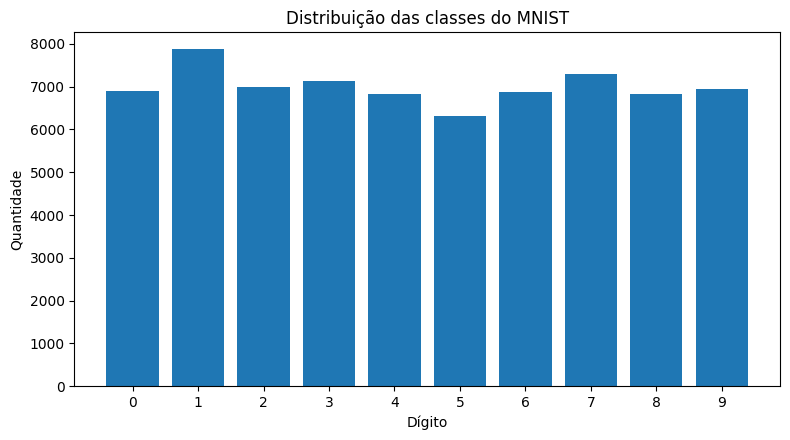

In [2]:
# Fonte primária: TensorFlow/Keras. Fallbacks: Google Drive público e upload manual no Colab.
import hashlib

MNIST_DRIVE_ID = "1x6s9JFgN5AVv72ZleY2Jp5pyKo-VgPn-"
MNIST_SHA256 = "731c5ac602752760c8e48fbffcf8c3b850d9dc2a2aedcf2cc48468fc17b673d1"


def carregar_mnist():
    try:
        treino, teste = mnist.load_data()
        return treino, teste, "TensorFlow/Keras"
    except Exception as erro_oficial:
        backup = ROOT / "data" / "mnist.npz"
        url = f"https://drive.usercontent.google.com/download?id={MNIST_DRIVE_ID}&export=download&confirm=t"
        try:
            urllib.request.urlretrieve(url, backup)
            origem = "Google Drive"
        except Exception as erro_drive:
            if "google.colab" not in sys.modules:
                raise RuntimeError("Falharam a fonte oficial e o backup público do MNIST.") from erro_drive
            from google.colab import files
            enviados = files.upload()  # botão de upload manual
            candidatos = [nome for nome in enviados if nome.lower().endswith(".npz")]
            if not candidatos:
                raise RuntimeError("Envie o arquivo mnist.npz.") from erro_oficial
            backup.write_bytes(enviados[candidatos[0]])
            origem = "upload manual"

        if hashlib.sha256(backup.read_bytes()).hexdigest() != MNIST_SHA256:
            raise ValueError("Backup MNIST inválido ou corrompido: SHA-256 divergente.")
        with np.load(backup) as f:
            treino = (f["x_train"], f["y_train"])
            teste = (f["x_test"], f["y_test"])
        return treino, teste, origem


(x_a, y_a), (x_b, y_b), fonte_mnist = carregar_mnist()
X_images = np.concatenate([x_a, x_b], axis=0).astype(np.uint8, copy=False)
y = np.concatenate([y_a, y_b], axis=0).astype(np.uint8, copy=False)
X_raw = X_images.reshape(len(X_images), -1)  # Apresentação: 28×28 → 784 atributos, sem alterar os pixels.

print("Fonte MNIST:", fonte_mnist)
print("X_images:", X_images.shape, X_images.dtype)
print("X vetorizado:", X_raw.shape, X_raw.dtype)
print("y:", y.shape, y.dtype)
print("Intervalo dos pixels:", (int(X_raw.min()), int(X_raw.max())))
print("Classes:", np.unique(y))

distribuicao = pd.Series(y).value_counts().sort_index().rename_axis("digito").to_frame("quantidade")
display(distribuicao)
assert X_raw.shape == (70000, 784)
assert y.shape == (70000,)
assert np.array_equal(np.unique(y), np.arange(10))

distribuicao.to_csv(ROOT / "outputs" / "tables" / "class_distribution.csv")
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(distribuicao.index.astype(str), distribuicao["quantidade"].values)
ax.set_title("Distribuição das classes do MNIST")
ax.set_xlabel("Dígito"); ax.set_ylabel("Quantidade")
fig.tight_layout(); fig.savefig(ROOT / "outputs" / "figures" / "class_distribution.png", dpi=160, bbox_inches="tight"); plt.show()


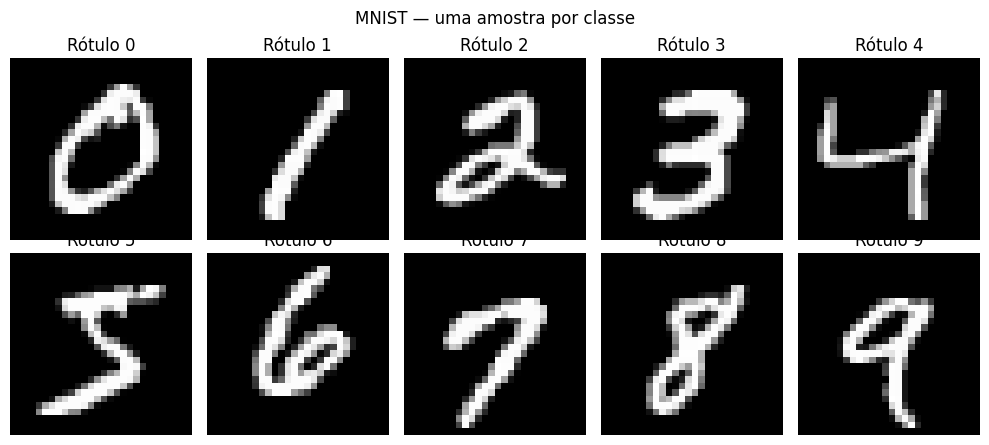

In [3]:
# Grade 2×5 com um exemplo original de cada classe.
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for digit, ax in enumerate(axes.flat):
    idx = int(np.flatnonzero(y == digit)[0])
    ax.imshow(X_images[idx], cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"Rótulo {digit}")
    ax.axis("off")
fig.suptitle("MNIST — uma amostra por classe")
plt.tight_layout()
fig.savefig(ROOT / "outputs" / "figures" / "eda_grid_2x5.png", dpi=160, bbox_inches="tight")
plt.show()

### **Interpretação da estrutura dos dados**

Cada imagem contém **28 × 28 = 784 pixels**. Na representação original, os valores variam de 0 a 255: valores baixos representam o fundo escuro e valores altos representam o traço claro. O `reshape` apenas reorganiza esses mesmos valores em um vetor de **784 features**, sem criar ou eliminar informação.

A distribuição das classes é próxima do balanceamento, mas não exatamente uniforme. Por isso, a divisão seguinte é estratificada para preservar a participação relativa dos dígitos em treino, validação e teste.

### **Eficiência de memória: manter inteiro enquanto possível**

O MNIST chega com pixels inteiros entre **0 e 255**. Por isso, a representação bruta é mantida em `uint8` (1 byte por pixel) até a divisão dos dados. Converter toda a base antecipadamente para ponto flutuante aumentaria o consumo de memória sem acrescentar informação.

| Tipo | Bytes por pixel | Base completa (70.000 × 784) | Treino (49.000 × 784) |
|---|---:|---:|---:|
| `uint8` | 1 | **54,88 MB** | **38,42 MB** |
| `float32` | 4 | 219,52 MB | 153,66 MB |
| `float64` | 8 | 439,04 MB | 307,33 MB |

Assim, a base bruta em `uint8` ocupa **8 vezes menos memória que em `float64`**. A conversão ocorre apenas quando o modelo precisa trabalhar com valores normalizados em `[0,1]`: a **Regressão Logística** recebe `float64`, enquanto **Random Forest** e **MLP Keras** recebem `float32`.

> **Decisão de projeto:** começar pela representação mais econômica e promover o tipo apenas na etapa em que isso é necessário reduz o uso de memória sem alterar os dados, o split, os modelos ou as métricas.


## **2. Pré-processamento e divisão dos dados**

A base é dividida em **70% treino, 10% validação e 20% teste**, com `stratify` e semente 42 nas duas etapas. O conjunto de teste fica isolado da seleção dos modelos.

A normalização divide os pixels por 255, levando a escala de `[0,255]` para `[0,1]`. Regressão Logística utiliza `float64`; Random Forest e MLP utilizam `float32` para reduzir custo de memória.


### **2.1 Funções auxiliares da preparação dos dados**

Este bloco concentra apenas as rotinas de **split estratificado, validação dos índices e normalização** usadas nesta fase.


In [4]:
RANDOM_STATE = 42

def make_split_indices(y: np.ndarray, random_state: int = RANDOM_STATE) -> Dict[str, np.ndarray]:
    """Cria split exato 70/10/20 com estratificação em ambas as divisões."""
    all_idx = np.arange(len(y))
    dev_idx, test_idx = train_test_split(  # Apresentação: split estratificado preserva a proporção dos dígitos.
        all_idx,
        test_size=0.20,
        stratify=y,
        random_state=random_state,
    )
    train_idx, val_idx = train_test_split(
        dev_idx,
        test_size=0.125,  # 7.000 de 56.000 = 10% do total
        stratify=y[dev_idx],
        random_state=random_state,
    )
    splits = {"train": train_idx, "validation": val_idx, "test": test_idx}
    validate_split_indices(y, splits)
    return splits

def validate_split_indices(y: np.ndarray, splits: Dict[str, np.ndarray]) -> None:
    expected = {"train": 49000, "validation": 7000, "test": 14000}
    for name, size in expected.items():
        if len(splits[name]) != size:
            raise ValueError(f"{name}: esperado {size}, obtido {len(splits[name])}")
    names = list(splits)
    for i, left in enumerate(names):
        for right in names[i + 1 :]:
            if np.intersect1d(splits[left], splits[right]).size:
                raise ValueError(f"Sobreposição entre {left} e {right}.")
    union = np.concatenate([splits[n] for n in names])
    if len(np.unique(union)) != len(y):
        raise ValueError("O split não cobre exatamente toda a base.")
    for name, idx in splits.items():
        if not np.array_equal(np.unique(y[idx]), np.arange(10)):
            raise ValueError(f"{name} não contém todas as classes.")

def save_split_indices(splits: Dict[str, np.ndarray], path: str | Path) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(path, **splits)

def normalize_for_family(x_raw: np.ndarray, family: str) -> np.ndarray:
    """Normaliza [0,255] -> [0,1] preservando dtype definido por família."""
    family = family.lower()
    if family == "lr":
        dtype = np.float64
    elif family in {"rf", "mlp"}:
        dtype = np.float32
    else:
        raise ValueError(f"Família desconhecida: {family}")
    x = x_raw.astype(dtype, copy=False) / dtype(255.0)  # Apresentação: converte só quando necessário; evita cópia extra.
    if x.min() < 0 or x.max() > 1:
        raise ValueError("Normalização fora de [0,1].")
    return x


In [5]:
splits = make_split_indices(y, random_state=SEED)
train_idx, val_idx, test_idx = splits["train"], splits["validation"], splits["test"]
save_split_indices(splits, ROOT / "artifacts" / "split_indices.npz")

# Checagens explícitas de tamanho e ausência de sobreposição.
assert (len(train_idx), len(val_idx), len(test_idx)) == (49000, 7000, 14000)
assert np.intersect1d(train_idx, val_idx).size == 0
assert np.intersect1d(train_idx, test_idx).size == 0
assert np.intersect1d(val_idx, test_idx).size == 0

y_train, y_val, y_test = y[train_idx], y[val_idx], y[test_idx]
X_lr_train = normalize_for_family(X_raw[train_idx], "lr")
X_lr_val = normalize_for_family(X_raw[val_idx], "lr")
X_lr_test = normalize_for_family(X_raw[test_idx], "lr")
X_f32_train = normalize_for_family(X_raw[train_idx], "mlp")
X_f32_val = normalize_for_family(X_raw[val_idx], "mlp")
X_f32_test = normalize_for_family(X_raw[test_idx], "mlp")

for nome, idx in {"treino": train_idx, "validacao": val_idx, "teste": test_idx}.items():
    print(nome, len(idx), pd.Series(y[idx]).value_counts().sort_index().to_dict())
print("Escala normalizada:", float(X_f32_train.min()), "a", float(X_f32_train.max()))

treino 49000 {0: 4832, 1: 5514, 2: 4893, 3: 4999, 4: 4777, 5: 4419, 6: 4813, 7: 5105, 8: 4777, 9: 4871}
validacao 7000 {0: 690, 1: 788, 2: 699, 3: 714, 4: 682, 5: 631, 6: 688, 7: 729, 8: 683, 9: 696}
teste 14000 {0: 1381, 1: 1575, 2: 1398, 3: 1428, 4: 1365, 5: 1263, 6: 1375, 7: 1459, 8: 1365, 9: 1391}
Escala normalizada: 0.0 a 1.0


### **2.2 Justificativa técnica**

A estratificação reduz o risco de um subconjunto ficar artificialmente mais concentrado em determinadas classes. As verificações de interseção tornam a ausência de *data leakage* entre os conjuntos uma propriedade testável.

Dividir por 255 melhora o condicionamento de modelos otimizados por gradiente, como Regressão Logística e MLP. Em algoritmos baseados em distância, escalas diferentes também podem distorcer a métrica. Árvores não exigem essa normalização para definir cortes, mas a representação comum simplifica o pipeline. Como 255 é uma constante conhecida, essa transformação não estima parâmetros a partir do teste.


## **3. Implementação e treinamento dos três modelos**

Foram comparadas três famílias distintas: **Regressão Logística multinomial**, **Random Forest** e **MLP (Multilayer Perceptron) com TensorFlow/Keras**.

Cada família varia pelo menos dois hiperparâmetros: na Regressão Logística, `C` e `solver`; na Random Forest, `n_estimators` e `max_depth`; na MLP, número de neurônios e taxa de aprendizado. A seleção usa apenas treino e validação, com F1 ponderado e Accuracy como critérios registrados no pipeline.


### **3.1 Funções auxiliares de avaliação e modelagem**

As rotinas abaixo calculam as métricas exigidas, constroem os três modelos e executam a seleção de hiperparâmetros usando somente treino e validação.


In [6]:
#@title Funções auxiliares de avaliação e modelagem { display-mode: "form" }
def classification_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision_weighted": float(precision_score(y_true, y_pred, average="weighted", zero_division=0)),
        "recall_weighted": float(recall_score(y_true, y_pred, average="weighted", zero_division=0)),
        "f1_weighted": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
    }

def confusion_10x10(y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(10))
    if cm.shape != (10, 10):
        raise ValueError(f"Matriz esperada 10x10; obtida {cm.shape}")
    return cm

def top_confusions(cm: np.ndarray, top_n: int = 8) -> pd.DataFrame:
    """Ordena erros por contagem e calcula taxa relativa por classe real."""
    rows: list[dict[str, float | int]] = []
    totals = cm.sum(axis=1)
    for true_label in range(cm.shape[0]):
        for pred_label in range(cm.shape[1]):
            if true_label == pred_label or cm[true_label, pred_label] == 0:
                continue
            count = int(cm[true_label, pred_label])
            rate = float(count / totals[true_label]) if totals[true_label] else 0.0
            rows.append(
                {
                    "real": true_label,
                    "predita": pred_label,
                    "casos": count,
                    "taxa_relativa": rate,
                }
            )
    frame = pd.DataFrame(rows, columns=["real", "predita", "casos", "taxa_relativa"])
    if frame.empty:
        return frame
    return frame.sort_values(
        ["casos", "taxa_relativa"], ascending=False
    ).head(top_n).reset_index(drop=True)

def plot_confusion_matrix(
    cm: np.ndarray,
    title: str,
    output_path: str | Path,
    x_labels: list[int] | np.ndarray | None = None,
    y_labels: list[int] | np.ndarray | None = None,
) -> None:
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig, ax = plt.subplots(figsize=(9, 7.5), facecolor="#F7F9FC")
    ax.set_facecolor("#F7F9FC")
    image = ax.imshow(cm, interpolation="nearest", cmap="Blues", vmin=0, vmax=max(1, cm.max()))
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title)
    ax.set_xlabel("Classe predita")
    ax.set_ylabel("Classe real")
    x_labels = np.arange(cm.shape[1]) if x_labels is None else np.asarray(x_labels)
    y_labels = np.arange(cm.shape[0]) if y_labels is None else np.asarray(y_labels)
    ax.set_xticks(np.arange(len(x_labels)), labels=x_labels)
    ax.set_yticks(np.arange(len(y_labels)), labels=y_labels)
    threshold = cm.max() * 0.55 if cm.size else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center", fontsize=9, fontweight="bold",
                    color="white" if cm[i, j] > threshold else "#111827")
    fig.tight_layout()
    fig.savefig(output_path, dpi=160, bbox_inches="tight")
    plt.close(fig)

def metrics_table(metrics_by_model: dict[str, dict[str, float]]) -> pd.DataFrame:
    frame = pd.DataFrame.from_dict(metrics_by_model, orient="index")
    frame.index.name = "modelo"
    return frame.reset_index()



@dataclass(frozen=True)
class MLPConfig:
    hidden1: int = 128
    hidden2: int = 64
    learning_rate: float = 1e-3
    batch_size: int = 128

def build_logistic_regression(C: float = 1.0, solver: str = "lbfgs") -> LogisticRegression:
    return LogisticRegression(
        C=C,
        solver=solver,
        max_iter=400,
        tol=1e-4,
        random_state=RANDOM_STATE,
    )

def build_random_forest(
    n_estimators: int = 160,
    max_depth: int | None = None,
    n_jobs: int = 2,
) -> RandomForestClassifier:
    return RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=RANDOM_STATE,
        n_jobs=n_jobs,
        class_weight=None,
    )

def build_mlp(
    output_units: int = 10,
    config: MLPConfig = MLPConfig(),
    seed: int = RANDOM_STATE,
) -> tf.keras.Model:
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)
    model = tf.keras.Sequential(
        [
            tf.keras.Input(shape=(784,)),
            tf.keras.layers.Dense(config.hidden1, activation="relu"),
            tf.keras.layers.Dense(config.hidden2, activation="relu"),
            tf.keras.layers.Dense(output_units, activation="softmax"),
        ],
        name="digit_mlp",
    )
    optimizer = tf.keras.optimizers.Adam(learning_rate=config.learning_rate)
    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

def fit_mlp(
    model: tf.keras.Model,
    x_train: np.ndarray,
    y_train: np.ndarray,
    x_val: np.ndarray,
    y_val: np.ndarray,
    config: MLPConfig,
    epochs: int = 15,
    patience: int = 3,
    verbose: int = 0,
) -> tuple[tf.keras.callbacks.History, float]:
    callback = tf.keras.callbacks.EarlyStopping(  # Apresentação: interrompe no melhor ponto e restaura os melhores pesos.
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True,
    )
    start = time.perf_counter()
    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=epochs,
        batch_size=config.batch_size,
        callbacks=[callback],
        verbose=verbose,
        shuffle=True,
    )
    return history, time.perf_counter() - start

def predict_proba(model: Any, x: np.ndarray) -> np.ndarray:
    """Uniformiza predict_proba entre sklearn e Keras."""
    if isinstance(model, tf.keras.Model):
        proba = model(x, training=False).numpy()
    elif hasattr(model, "predict_proba"):
        proba = model.predict_proba(x)
    else:
        raise TypeError("Modelo não fornece probabilidades.")
    proba = np.asarray(proba)
    if proba.ndim != 2 or not np.isfinite(proba).all():
        raise ValueError("Probabilidades inválidas.")
    return proba

def predict_labels(model: Any, x: np.ndarray, classes: np.ndarray | None = None) -> np.ndarray:
    if isinstance(model, tf.keras.Model):
        idx = predict_proba(model, x).argmax(axis=1)
        return idx if classes is None else np.asarray(classes)[idx]
    return np.asarray(model.predict(x))


In [7]:
#@title Treino e seleção dos três modelos { display-mode: "form" }
def _acceptable(base: dict[str, float], candidate: dict[str, float]) -> bool:
    return candidate["accuracy"] >= base["accuracy"] and candidate["f1_weighted"] >= base["f1_weighted"]

def _fit_lr(x_train: np.ndarray, y_train: np.ndarray, x_val: np.ndarray, y_val: np.ndarray) -> tuple[Any, dict[str, Any]]:
    baseline = build_logistic_regression(C=1.0, solver="lbfgs")
    start = time.perf_counter()
    baseline.fit(x_train, y_train)
    baseline_seconds = time.perf_counter() - start
    baseline_metrics = classification_metrics(y_val, baseline.predict(x_val))
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    search = GridSearchCV(
        estimator=build_logistic_regression(),
        param_grid={"C": [0.7, 1.0], "solver": ["lbfgs", "newton-cg"]},
        scoring="f1_weighted",
        cv=cv,
        n_jobs=2,
        refit=True,
        return_train_score=False,
    )
    start = time.perf_counter()
    search.fit(x_train, y_train)
    search_seconds = time.perf_counter() - start
    candidate = search.best_estimator_
    candidate_metrics = classification_metrics(y_val, candidate.predict(x_val))
    accepted = _acceptable(baseline_metrics, candidate_metrics)
    final_model = candidate if accepted else baseline
    info = {
        "baseline": {"params": baseline.get_params(), "validation": baseline_metrics, "fit_seconds": baseline_seconds},
        "search_best_params": search.best_params_,
        "search_best_cv_f1_weighted": float(search.best_score_),
        "search_seconds": search_seconds,
        "candidate_validation": candidate_metrics,
        "candidate_accepted": accepted,
        "selected_params": final_model.get_params(),
        "selected_validation": candidate_metrics if accepted else baseline_metrics,
    }
    return final_model, info

def _fit_rf(x_train: np.ndarray, y_train: np.ndarray, x_val: np.ndarray, y_val: np.ndarray) -> tuple[Any, dict[str, Any]]:
    baseline = build_random_forest(n_estimators=160, max_depth=None)
    start = time.perf_counter()
    baseline.fit(x_train, y_train)
    baseline_seconds = time.perf_counter() - start
    baseline_metrics = classification_metrics(y_val, baseline.predict(x_val))
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    search = GridSearchCV(
        estimator=build_random_forest(),
        param_grid={"n_estimators": [160, 240], "max_depth": [None, 28]},
        scoring="f1_weighted",
        cv=cv,
        n_jobs=2,
        refit=True,
        return_train_score=False,
    )
    start = time.perf_counter()
    search.fit(x_train, y_train)
    search_seconds = time.perf_counter() - start
    candidate = search.best_estimator_
    candidate_metrics = classification_metrics(y_val, candidate.predict(x_val))
    accepted = _acceptable(baseline_metrics, candidate_metrics)
    final_model = candidate if accepted else baseline
    info = {
        "baseline": {"params": baseline.get_params(), "validation": baseline_metrics, "fit_seconds": baseline_seconds},
        "search_best_params": search.best_params_,
        "search_best_cv_f1_weighted": float(search.best_score_),
        "search_seconds": search_seconds,
        "candidate_validation": candidate_metrics,
        "candidate_accepted": accepted,
        "selected_params": final_model.get_params(),
        "selected_validation": candidate_metrics if accepted else baseline_metrics,
    }
    return final_model, info

def _fit_mlp_candidates(x_train: np.ndarray, y_train: np.ndarray, x_val: np.ndarray, y_val: np.ndarray) -> tuple[tf.keras.Model, MLPConfig, dict[str, Any]]:
    configs = [
        MLPConfig(128, 64, 1e-3, 128),
        MLPConfig(128, 64, 5e-4, 128),
        MLPConfig(192, 96, 1e-3, 128),
        MLPConfig(192, 96, 5e-4, 128),
    ]
    results: list[dict[str, Any]] = []
    models: list[tf.keras.Model] = []
    for idx, config in enumerate(configs):
        model = build_mlp(output_units=10, config=config, seed=SEED)
        history, fit_seconds = fit_mlp(
            model,
            x_train,
            y_train,
            x_val,
            y_val,
            config=config,
            epochs=15,
            patience=3,
            verbose=0,
        )
        pred = predict_labels(model, x_val)
        metrics = classification_metrics(y_val, pred)
        results.append(
            {
                "config": config.__dict__,
                "validation": metrics,
                "fit_seconds": fit_seconds,
                "epochs_ran": len(history.history["loss"]),
                "best_val_loss": float(min(history.history["val_loss"])),
            }
        )
        models.append(model)
    baseline_metrics = results[0]["validation"]
    admissible = [0] + [i for i in range(1, len(results)) if _acceptable(baseline_metrics, results[i]["validation"])]
    selected_idx = max(
        admissible,
        key=lambda i: (
            results[i]["validation"]["f1_weighted"],
            results[i]["validation"]["accuracy"],
            -results[i]["fit_seconds"],
        ),
    )
    for i, row in enumerate(results):
        row["admissible_vs_baseline"] = i == 0 or _acceptable(baseline_metrics, row["validation"])
        row["selected"] = i == selected_idx
    return models[selected_idx], configs[selected_idx], {
        "baseline_validation": baseline_metrics,
        "candidates": results,
        "selected_config": configs[selected_idx].__dict__,
        "selected_validation": results[selected_idx]["validation"],
    }

def _predict_with_timing(model: Any, x: np.ndarray, family: str) -> tuple[np.ndarray, np.ndarray, float]:
    start = time.perf_counter()
    probabilities = predict_proba(model, x)
    if family == "mlp":
        predictions = probabilities.argmax(axis=1)
    else:
        predictions = np.asarray(model.classes_)[probabilities.argmax(axis=1)]
    elapsed = time.perf_counter() - start
    return predictions, probabilities, elapsed


In [8]:
# Treino e seleção da Regressão Logística, Random Forest e MLP sem consultar o teste.
lr_model, lr_info = _fit_lr(X_lr_train, y_train, X_lr_val, y_val)
rf_model, rf_info = _fit_rf(X_f32_train, y_train, X_f32_val, y_val)
mlp_model, mlp_config, mlp_info = _fit_mlp_candidates(X_f32_train, y_train, X_f32_val, y_val)

validation_scores = {
    "Logistic Regression": lr_info["selected_validation"],
    "Random Forest": rf_info["selected_validation"],
    "MLP Keras": mlp_info["selected_validation"],
}
champion = max(
    validation_scores,
    key=lambda nome: (validation_scores[nome]["f1_weighted"], validation_scores[nome]["accuracy"]),
)
selection = {
    "protocol": "selection_on_validation_only",
    "champion": champion,
    "champion_family": {"Logistic Regression":"lr", "Random Forest":"rf", "MLP Keras":"mlp"}[champion],
    "validation_scores": validation_scores,
    "lr": lr_info, "rf": rf_info, "mlp": mlp_info,
}
(ROOT / "artifacts").mkdir(parents=True, exist_ok=True)
(ROOT / "artifacts" / "selection.json").write_text(json.dumps(selection, indent=2, ensure_ascii=False), encoding="utf-8")

model_dir = ROOT / "artifacts" / "models"
model_dir.mkdir(parents=True, exist_ok=True)
joblib.dump(lr_model, model_dir / "logistic_regression.joblib", compress=3)
joblib.dump(rf_model, model_dir / "random_forest.joblib", compress=3)
mlp_model.save(model_dir / "mlp.keras")

print("Campeão selecionado na validação:", champion)
display(pd.DataFrame(validation_scores).T)
print("LR selecionado:", lr_info["selected_params"])
print("RF selecionado:", rf_info["selected_params"])
print("MLP selecionada:", mlp_info["selected_config"])

Campeão selecionado na validação: MLP Keras


,accuracy,precision_weighted,recall_weighted,f1_weighted
Logistic Regression,0.923429,0.923326,0.923429,0.923275
Random Forest,0.967857,0.967880,0.967857,0.967828
MLP Keras,0.975857,0.976026,0.975857,0.975820


LR selecionado: {'C': 0.7, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 400, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'newton-cg', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}
RF selecionado: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 160, 'n_jobs': 2, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}
MLP selecionada: {'hidden1': 192, 'hidden2': 96, 'learning_rate': 0.0005, 'batch_size': 128}


### **Interpretação da seleção**

Na validação, a **MLP Keras foi a melhor opção**, com **97,59% de Accuracy** e **97,58% de F1 ponderado**, acima do Random Forest (**96,79%**) e da Regressão Logística (**92,34%**). A configuração selecionada foi **192 → 96 neurônios**, `learning_rate=0,0005` e `batch_size=128`.

A escolha foi feita **somente com o conjunto de validação**, sem consultar o teste final. Isso evita favorecer o modelo com base nos mesmos dados usados depois para medir seu desempenho definitivo.

### **3.2 Arquitetura do modelo campeão**

A MLP recebe **784 atributos**, passa por duas camadas densas e produz dez probabilidades Softmax. A figura persistida abaixo documenta a arquitetura; o resumo do próprio modelo executado é exibido em seguida.


Model: "digit_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 192)            │       150,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 96)             │        18,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 510,656 (1.95 MB)

 Trainable params: 170,218 (664.91 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 340,438 (1.30 MB)

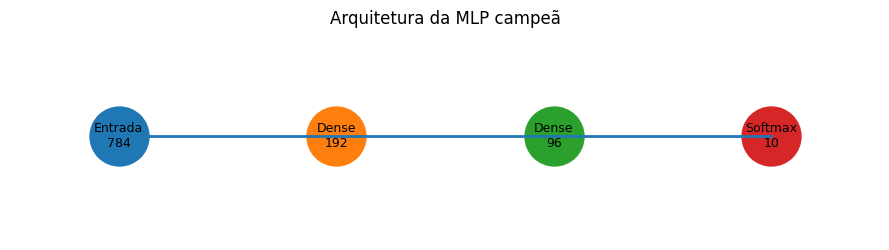

In [9]:
mlp_model.summary()
fig_path = ROOT / "outputs" / "figures" / "mlp_architecture.png"
camadas = [("Entrada", 784), ("Dense", mlp_config.hidden1), ("Dense", mlp_config.hidden2), ("Softmax", 10)]
fig, ax = plt.subplots(figsize=(9, 2.6))
xpos = np.arange(len(camadas))
ax.plot(xpos, np.zeros_like(xpos), linewidth=2)
for x, (nome, unidades) in zip(xpos, camadas):
    ax.scatter(x, 0, s=1800)
    ax.text(x, 0, f"{nome}\n{unidades}", ha="center", va="center", fontsize=9)
ax.set_xlim(-0.5, len(camadas)-0.5); ax.set_ylim(-0.8,0.8); ax.axis("off")
ax.set_title("Arquitetura da MLP campeã")
fig.tight_layout(); fig.savefig(fig_path, dpi=160, bbox_inches="tight"); plt.show()


**Leitura do output — arquitetura da MLP:** a rede recebe **784 atributos**, passa por camadas densas de **192** e **96 neurônios** e termina em **10 saídas Softmax**. As camadas somam **170.218 parâmetros treináveis**; o total de **510.656** exibido pelo Keras inclui também os estados internos do otimizador Adam. A arquitetura é compacta para o MNIST e preserva capacidade não linear sem recorrer a uma CNN.


## **4. Avaliação comparativa no teste independente**

Somente depois de congelar as escolhas na validação, os três modelos são avaliados nos **14.000 exemplos de teste**. Para cada modelo são calculados Accuracy, Precision ponderada, Recall ponderado e F1 ponderado, além de matriz de confusão completa 10×10.


In [10]:
# Avalio os três modelos somente depois da seleção na validação, preservando o teste como medida independente.
models = {"Logistic Regression": lr_model, "Random Forest": rf_model, "MLP Keras": mlp_model}
families = {"Logistic Regression":"lr", "Random Forest":"rf", "MLP Keras":"mlp"}
test_inputs = {"Logistic Regression": X_lr_test, "Random Forest": X_f32_test, "MLP Keras": X_f32_test}

test_metrics, predictions, probabilities, timings = {}, {}, {}, {}
for nome, modelo in models.items():
    pred, proba, elapsed = _predict_with_timing(modelo, test_inputs[nome], families[nome])
    predictions[nome], probabilities[nome], timings[nome] = pred, proba, elapsed
    test_metrics[nome] = classification_metrics(y_test, pred)

benchmark = metrics_table(test_metrics)
benchmark.to_csv(ROOT / "outputs" / "tables" / "benchmark_metrics.csv", index=False)
(ROOT / "artifacts" / "timings.json").write_text(json.dumps(timings, indent=2), encoding="utf-8")
display(benchmark)


,modelo,accuracy,precision_weighted,recall_weighted,f1_weighted
0,Logistic Regression,0.920500,0.920216,0.920500,0.920280
1,Random Forest,0.966357,0.966360,0.966357,0.966340
2,MLP Keras,0.975000,0.975135,0.975000,0.974961


**Leitura do output — avaliação comparativa:** no teste independente de **14.000 imagens**, a Regressão Logística atingiu **92,05% de Accuracy**, o Random Forest **96,64%** e a **MLP Keras 97,50%**. O F1 ponderado segue a mesma ordem (**92,03%**, **96,63%** e **97,50%**), confirmando que a MLP manteve a melhor generalização também fora do conjunto usado para seleção.


### **4.1 Custo computacional × desempenho**

Além da qualidade preditiva, o experimento registra o custo do protocolo de seleção e o tempo de inferência do lote completo de teste. Esses tempos descrevem **esta execução e este ambiente**; não são um benchmark universal entre arquiteturas.


In [11]:
# Comparo custo de seleção e tempo de inferência; são custos distintos e dependem do protocolo e do hardware.
cost = pd.DataFrame([
    {"modelo":"Logistic Regression", "selecao_s": lr_info["baseline"]["fit_seconds"] + lr_info["search_seconds"], "inferencia_14k_s": timings["Logistic Regression"]},
    {"modelo":"Random Forest", "selecao_s": rf_info["baseline"]["fit_seconds"] + rf_info["search_seconds"], "inferencia_14k_s": timings["Random Forest"]},
    {"modelo":"MLP Keras", "selecao_s": sum(c["fit_seconds"] for c in mlp_info["candidates"]), "inferencia_14k_s": timings["MLP Keras"]},
])
display(cost)


,modelo,selecao_s,inferencia_14k_s
0,Logistic Regression,518.930077,0.054752
1,Random Forest,713.457075,0.724652
2,MLP Keras,115.781540,0.136591


#### **Interpretação do desempenho**

Nesta execução, o custo do protocolo de seleção foi de aproximadamente **518,93 s** para a Regressão Logística, **713,46 s** para o Random Forest e **115,78 s** para a MLP Keras.

Na inferência das **14.000 imagens do conjunto de teste**, os tempos foram aproximadamente **0,055 s**, **0,725 s** e **0,137 s**, respectivamente.

Assim, a **Regressão Logística apresentou a menor latência de inferência em lote**, enquanto a **MLP apresentou o melhor desempenho preditivo e o menor custo de seleção neste protocolo específico**. O Random Forest apresentou o maior custo tanto na seleção quanto na inferência entre os três modelos nesta execução.

Esses tempos dependem do procedimento de ajuste, hardware, bibliotecas, paralelismo e condições do ambiente de execução. Portanto, **não representam uma superioridade computacional universal de um algoritmo sobre os demais**.

### **4.2 Matrizes de confusão e diagnóstico de erros**

As três matrizes **10×10** mostram uma progressão clara de qualidade: quanto maior a concentração na diagonal, menor o número de classificações incorretas.

- **Regressão Logística:** o erro dominante é **4→9** (55 casos na execução apresentada), seguido de **3→5** (51). Isso mostra a limitação do separador linear diante de grafias com traços semelhantes.
- **Random Forest:** reduz substancialmente os erros fora da diagonal; **4→9** permanece como a principal confusão, porém com incidência menor. O ganho indica que relações não lineares entre pixels ajudam a separar os dígitos.
- **MLP Keras:** apresenta a diagonal mais concentrada e o menor erro global. As confusões residuais concentram-se principalmente em **9→4**, além de **9→7** e **3→5/7**, pares visualmente próximos.

**Conclusão:** as matrizes confirmam a mesma ordem observada nas métricas agregadas: **MLP > Random Forest > Regressão Logística**. A MLP não apenas alcança maior Accuracy/F1; ela também reduz os padrões sistemáticos de confusão entre classes, restando sobretudo ambiguidades de forma entre dígitos semelhantes.


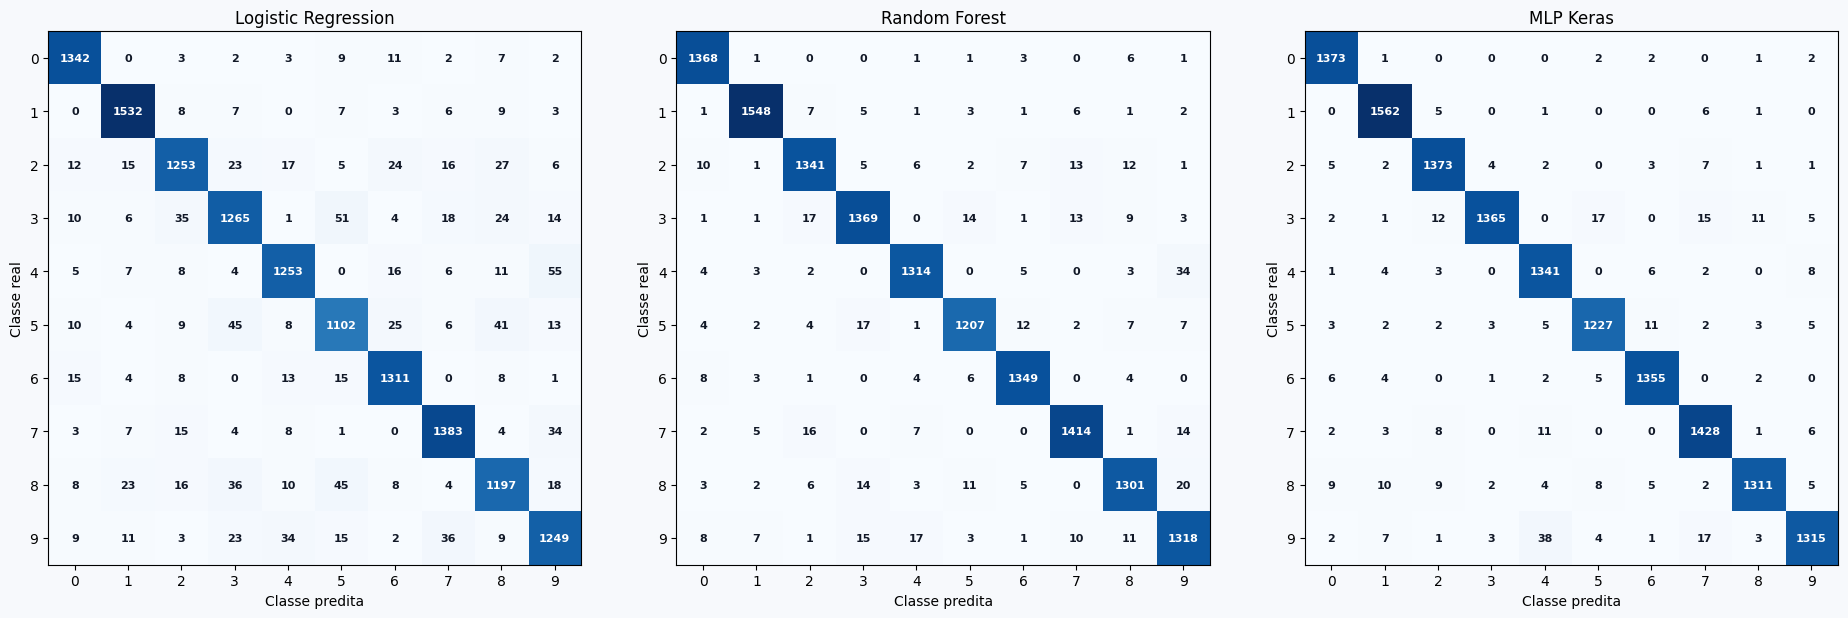

In [12]:
# Construo uma matriz 10×10 por modelo para localizar acertos na diagonal e erros sistemáticos fora dela.
confusions = {}
fig, axes = plt.subplots(1, 3, figsize=(19, 6), facecolor="#F7F9FC")
for ax, (nome, pred) in zip(axes, predictions.items()):
    cm = confusion_10x10(y_test, pred)
    confusions[nome] = cm
    ax.set_facecolor("#F7F9FC")
    ax.imshow(cm, interpolation="nearest", cmap="Blues", vmin=0, vmax=max(1, cm.max()))
    ax.set_title(nome)
    ax.set_xlabel("Classe predita"); ax.set_ylabel("Classe real")
    ax.set_xticks(range(10)); ax.set_yticks(range(10))
    for i in range(10):
        for j in range(10):
            ax.text(j, i, int(cm[i,j]), ha="center", va="center", fontsize=8, fontweight="bold",
                    color="white" if cm[i,j] > cm.max()*0.55 else "#111827")
    stem = nome.lower().replace(" ", "_")
    np.savetxt(ROOT / "outputs" / "tables" / f"confusion_{stem}.csv", cm, delimiter=",", fmt="%d")
    plot_confusion_matrix(cm, f"Matriz de confusão — {nome}", ROOT / "outputs" / "figures" / f"confusion_{stem}.png")
plt.tight_layout()
plt.show()


In [13]:
# Extraio as maiores confusões fora da diagonal para identificar quais pares de dígitos ainda são mais problemáticos.
for nome, cm in confusions.items():
    erros = top_confusions(cm, top_n=5)
    stem = nome.lower().replace(" ", "_")
    erros.to_csv(ROOT / "outputs" / "tables" / f"top_confusions_{stem}.csv", index=False)
    print()
    print(nome)
    display(erros)



Logistic Regression


,real,predita,casos,taxa_relativa
0,4,9,55,0.040293
1,3,5,51,0.035714
2,5,3,45,0.035629
3,8,5,45,0.032967
4,5,8,41,0.032462



Random Forest


,real,predita,casos,taxa_relativa
0,4,9,34,0.024908
1,8,9,20,0.014652
2,5,3,17,0.013460
3,9,4,17,0.012221
4,3,2,17,0.011905



MLP Keras


,real,predita,casos,taxa_relativa
0,9,4,38,0.027318
1,9,7,17,0.012221
2,3,5,17,0.011905
3,3,7,15,0.010504
4,3,2,12,0.008403


### **4.3 Conclusão técnica da comparação**

O **MLP Keras apresentou a melhor performance global**. Na execução validada, suas confusões mais frequentes ficaram concentradas em grafias visualmente próximas, como **9→4** e **3→5/7**.

A leitura de custo confirma que desempenho não deve ser resumido à acurácia: treinamento/seleção e inferência são custos diferentes. A MLP combinou o melhor resultado preditivo com inferência em lote muito rápida depois de carregada.


## **5. Robustez e generalização**

### **5.1 Desafio A — Class Masking**

As classes **4 e 7** são removidas integralmente dos conjuntos de treino e validação do experimento restrito. A MLP mascarada possui somente oito saídas, correspondentes às classes efetivamente conhecidas. O objetivo é criar um cenário controlado em que o classificador nunca tenha ajustado pesos usando 4 ou 7.


Este bloco implementa o **Class Masking** e as medidas de incerteza usadas para separar exemplos conhecidos (ID) de classes ocultas (OOD).


In [14]:
DEFAULT_HIDDEN = (4, 7)

def known_classes(hidden: tuple[int, ...] = DEFAULT_HIDDEN) -> np.ndarray:
    classes = np.array([d for d in range(10) if d not in set(hidden)], dtype=np.uint8)
    return classes

def restrict_training(
    x: np.ndarray,
    y: np.ndarray,
    hidden: tuple[int, ...] = DEFAULT_HIDDEN,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    known = known_classes(hidden)
    mask = ~np.isin(y, hidden)  # Apresentação: remove 4 e 7 do treino para simular classes nunca vistas.
    if np.isin(y[mask], hidden).any():
        raise AssertionError("Classes ocultas permaneceram no treinamento.")
    mapping = {int(label): idx for idx, label in enumerate(known)}
    internal_y = np.asarray([mapping[int(label)] for label in y[mask]], dtype=np.int64)
    return x[mask], internal_y, known

def decode_internal(indices: np.ndarray, known: np.ndarray) -> np.ndarray:
    indices = np.asarray(indices, dtype=int)
    if indices.size and (indices.min() < 0 or indices.max() >= len(known)):
        raise ValueError("Índice interno fora do mapa de classes.")
    return np.asarray(known)[indices]

def predictive_entropy(probabilities: np.ndarray) -> np.ndarray:
    p = np.asarray(probabilities, dtype=np.float64)
    if p.ndim != 2 or np.any(p < 0):
        raise ValueError("Probabilidades devem formar matriz 2D não negativa.")
    row_sums = p.sum(axis=1)
    if not np.allclose(row_sums, 1.0, atol=1e-5):
        raise ValueError("Linhas de probabilidade devem somar 1.")
    return -(p * np.log(p + 1e-12)).sum(axis=1)

def uncertainty_summary(probabilities: np.ndarray) -> dict[str, float]:
    p = np.asarray(probabilities)
    msp = p.max(axis=1)
    entropy = predictive_entropy(p)
    return {
        "msp_mean": float(np.mean(msp)),
        "msp_median": float(np.median(msp)),
        "msp_p90": float(np.quantile(msp, 0.90)),
        "msp_p95": float(np.quantile(msp, 0.95)),
        "entropy_mean": float(np.mean(entropy)),
        "entropy_median": float(np.median(entropy)),
    }

def hidden_vs_known_matrix(
    y_hidden: np.ndarray,
    pred_known: np.ndarray,
    hidden: tuple[int, ...],
    known: np.ndarray,
) -> np.ndarray:
    matrix = np.zeros((len(hidden), len(known)), dtype=int)
    hidden_map = {label: i for i, label in enumerate(hidden)}
    known_map = {int(label): j for j, label in enumerate(known)}
    for truth, pred in zip(y_hidden, pred_known):
        if int(truth) in hidden_map and int(pred) in known_map:
            matrix[hidden_map[int(truth)], known_map[int(pred)]] += 1
    return matrix

def plot_uncertainty_distributions(
    id_probabilities: np.ndarray,
    ood_probabilities: np.ndarray,
    output_path: str | Path,
) -> None:
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    id_msp = id_probabilities.max(axis=1)
    ood_msp = ood_probabilities.max(axis=1)
    fig, ax = plt.subplots(figsize=(8, 5))
    bins = np.linspace(0, 1, 31)
    ax.hist(id_msp, bins=bins, alpha=0.55, density=True, label="ID")
    ax.hist(ood_msp, bins=bins, alpha=0.55, density=True, label="OOD")
    ax.set_xlabel("Maximum Softmax Probability (MSP)")
    ax.set_ylabel("Densidade")
    ax.set_title("Distribuição de confiança — ID vs OOD")
    ax.legend()
    fig.tight_layout()
    fig.savefig(output_path, dpi=160, bbox_inches="tight")
    plt.close(fig)


In [15]:
# Remove 4 e 7 do treino/validação e treina uma MLP com oito saídas.
X_mask_train, y_mask_train, known = restrict_training(X_f32_train, y_train, DEFAULT_HIDDEN)
X_mask_val, y_mask_val, known_val = restrict_training(X_f32_val, y_val, DEFAULT_HIDDEN)
assert np.array_equal(known, known_val)
assert not np.isin(y_train[~np.isin(y_train, DEFAULT_HIDDEN)], DEFAULT_HIDDEN).any()

masked_model = build_mlp(output_units=len(known), config=mlp_config, seed=SEED)
masked_history, masked_fit_seconds = fit_mlp(
    masked_model, X_mask_train, y_mask_train, X_mask_val, y_mask_val,
    config=mlp_config, epochs=15, patience=3, verbose=0
)
masked_model.save(ROOT / "artifacts" / "models" / "mlp_masked_4_7.keras")
np.save(ROOT / "artifacts" / "models" / "masked_known_classes.npy", known)
print("Classes ocultas:", DEFAULT_HIDDEN)
print("Classes conhecidas:", known.tolist())
print("Épocas executadas:", len(masked_history.history["loss"]))

Classes ocultas: (4, 7)
Classes conhecidas: [0, 1, 2, 3, 5, 6, 8, 9]
Épocas executadas: 14


### **Interpretação do mascaramento**

O modelo restrito não possui neurônios de saída para 4 e 7. Portanto, ao receber uma dessas classes no teste, ele será **forçado a escolher alguma classe conhecida**. Essa construção torna a análise OOD (Out-of-Distribution) explícita: o interesse não é apenas quantificar erro, mas observar para onde o modelo desloca sua confiança.


In [16]:
# Teste separado: ID = classes conhecidas; OOD = somente 4 e 7.
hidden_mask = np.isin(y_test, DEFAULT_HIDDEN)
known_mask = ~hidden_mask
id_proba = predict_proba(masked_model, X_f32_test[known_mask])
ood_proba = predict_proba(masked_model, X_f32_test[hidden_mask])
id_pred = decode_internal(id_proba.argmax(axis=1), known)
ood_pred = decode_internal(ood_proba.argmax(axis=1), known)

id_metrics = classification_metrics(y_test[known_mask], id_pred)
ood_matrix = hidden_vs_known_matrix(y_test[hidden_mask], ood_pred, DEFAULT_HIDDEN, known)
id_unc = uncertainty_summary(id_proba)
ood_unc = uncertainty_summary(ood_proba)

plot_confusion_matrix(ood_matrix, "Classes ocultas 4/7 → classes conhecidas",
    ROOT / "outputs" / "figures" / "ood_hidden_vs_known.png", x_labels=known, y_labels=np.asarray(DEFAULT_HIDDEN))
plot_uncertainty_distributions(id_proba, ood_proba,
    ROOT / "outputs" / "figures" / "ood_msp_id_vs_ood.png")

high_idx = np.argsort(ood_proba.max(axis=1))[::-1][:12]
high_conf = pd.DataFrame({
    "classe_real_oculta": y_test[hidden_mask][high_idx],
    "classe_atribuida": ood_pred[high_idx],
    "confianca_maxima": ood_proba.max(axis=1)[high_idx],
})
high_conf.to_csv(ROOT / "outputs" / "tables" / "ood_high_confidence_examples.csv", index=False)

ood_results = {
    "hidden_classes": list(DEFAULT_HIDDEN),
    "known_classes": known.astype(int).tolist(),
    "masked_model": "MLP Keras 8 outputs",
    "masked_epochs": len(masked_history.history["loss"]),
    "masked_fit_seconds": masked_fit_seconds,
    "id_metrics_known_classes": id_metrics,
    "id_uncertainty": id_unc,
    "ood_uncertainty": ood_unc,
    "ood_samples": int(hidden_mask.sum()),
}
(ROOT / "artifacts" / "ood_results.json").write_text(json.dumps(ood_results, indent=2), encoding="utf-8")
print("Amostras OOD:", int(hidden_mask.sum()))
display(pd.DataFrame({"ID": id_unc, "OOD": ood_unc}))
display(high_conf.head(8))

Amostras OOD: 2824


,ID,OOD
msp_mean,0.986397,0.873259
msp_median,0.999967,0.959438
msp_p90,1.000000,0.999743
msp_p95,1.000000,0.999940
entropy_mean,0.038895,0.336729
entropy_median,0.000397,0.194648


,classe_real_oculta,classe_atribuida,confianca_maxima
0,7,0,1.000000
1,4,9,1.000000
2,4,9,0.999999
3,4,9,0.999999
4,4,9,0.999999
5,4,9,0.999999
6,4,9,0.999999
7,4,9,0.999998


## **5.2 Desafio B — Inferência OOD e falsa certeza (*overconfidence*)**

A Maximum Softmax Probability (MSP) média caiu de aproximadamente **98,64% nas classes conhecidas (ID)** para **87,33% nas classes ocultas (OOD)**, enquanto a entropia média aumentou de cerca de **0,039 para 0,337**.

Mesmo assim, existem 4 e 7 nunca vistos que recebem probabilidade próxima de 100% para uma classe conhecida. **Softmax alto não comprova que a entrada pertence à distribuição de treinamento.** A matriz correspondente mostra quais classes conhecidas absorvem os dígitos ocultos.


### **Painel visual ID × OOD**

O painel amplia os dois artefatos do experimento mascarado: a distribuição da Maximum Softmax Probability (MSP) e a matriz que mostra para quais classes conhecidas os dígitos ocultos 4 e 7 são direcionados.


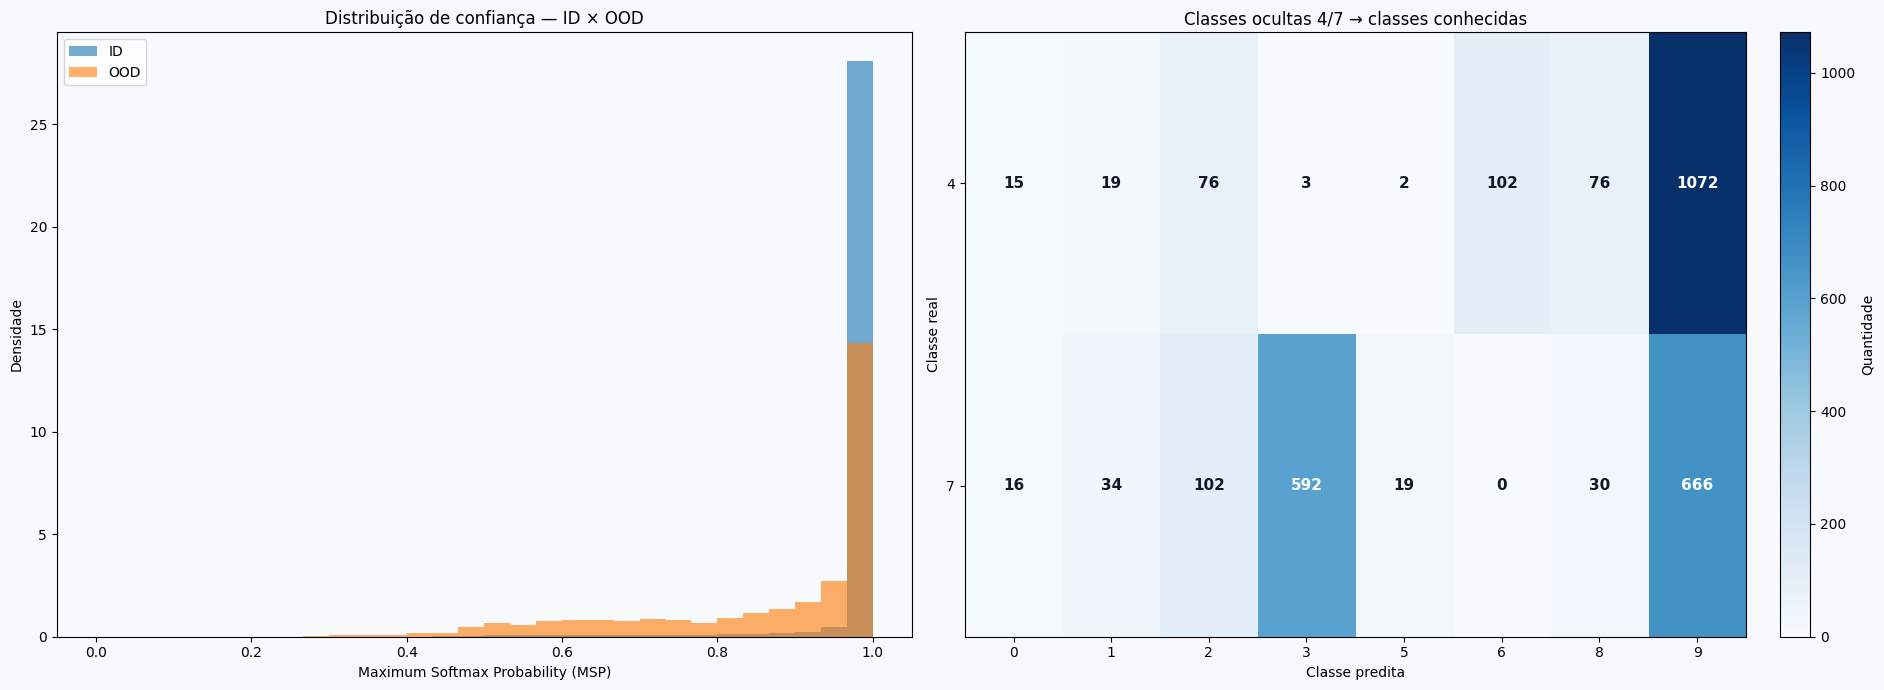

Exemplos OOD de maior confiança:


,classe_real_oculta,classe_atribuida,confianca_maxima
0,7,0,1.000000
1,4,9,1.000000
2,4,9,0.999999
3,4,9,0.999999
4,4,9,0.999999
5,4,9,0.999999
6,4,9,0.999999
7,4,9,0.999998


In [17]:
# Painel ampliado dos artefatos OOD: confiança ID/OOD e destino das classes ocultas.
fig, axes = plt.subplots(1, 2, figsize=(19, 7), facecolor="#F7F9FC")
for ax in axes: ax.set_facecolor("#F7F9FC")
bins = np.linspace(0, 1, 31)
axes[0].hist(id_proba.max(axis=1), bins=bins, alpha=.62, density=True, label="ID")
axes[0].hist(ood_proba.max(axis=1), bins=bins, alpha=.62, density=True, label="OOD")
axes[0].set(title="Distribuição de confiança — ID × OOD", xlabel="Maximum Softmax Probability (MSP)", ylabel="Densidade")
axes[0].legend()
im = axes[1].imshow(ood_matrix, cmap="Blues", aspect="auto", vmin=0, vmax=max(1, ood_matrix.max()))
axes[1].set(title="Classes ocultas 4/7 → classes conhecidas", xlabel="Classe predita", ylabel="Classe real")
axes[1].set_xticks(np.arange(len(known)), labels=known); axes[1].set_yticks(np.arange(len(DEFAULT_HIDDEN)), labels=DEFAULT_HIDDEN)
lim = ood_matrix.max() * .55
for i in range(ood_matrix.shape[0]):
    for j in range(ood_matrix.shape[1]):
        axes[1].text(j, i, int(ood_matrix[i,j]), ha="center", va="center", fontsize=11, fontweight="bold", color="white" if ood_matrix[i,j] > lim else "#111827")
fig.colorbar(im, ax=axes[1], fraction=.046, pad=.04, label="Quantidade")
fig.tight_layout(); fig.savefig(ROOT / "outputs" / "figures" / "ood_semantic_panel.png", dpi=180, bbox_inches="tight"); plt.show()
print("Exemplos OOD de maior confiança:"); display(high_conf.head(8))


**Leitura do output — painel ID × OOD:** as amostras conhecidas (ID) concentram confiança próxima de 1, enquanto as classes ocultas (OOD) apresentam distribuição mais espalhada e maior incerteza. Mesmo assim, há forte sobreposição: o dígito oculto **4 é frequentemente absorvido pela classe 9**, e o **7 principalmente por 9 e 3**. A tabela mostra ainda exemplos OOD com confiança praticamente **100%**, evidenciando que **Softmax alto não é garantia de que a entrada pertence ao domínio conhecido**.


## **6. Desafio C — Inferência com imagens manuscritas próprias**

A fotografia contém **14 dígitos manuscritos pelo autor**. A aquisição no notebook segue duas opções portáveis: primeiro tenta baixar `Numeros_manuscritos.jpg` diretamente do Google Drive; se o arquivo não puder ser obtido, o Google Colab abre o seletor de upload.

O pré-processamento segue o pipeline: correção EXIF, segmentação da tinta azul, componentes conectados, dilatação morfológica mínima, conversão para uma representação de traço claro em fundo escuro, bounding box, redimensionamento proporcional, centralização de massa em 28×28 e normalização `[0,1]`. **A mesma regra é aplicada às 14 amostras, sem ajuste manual por dígito.**


Na inferência externa da **MLP**, a probabilidade final usa a média de cinco versões do mesmo dígito (original e deslocamentos de 1 pixel). Essa *test-time augmentation* reduz sensibilidade a pequenos desalinhamentos da fotografia sem modificar o treinamento, a arquitetura ou as métricas do teste MNIST.


### **6.1 Funções auxiliares para imagens manuscritas**

Estas rotinas fazem segmentação, recorte, centralização e conversão das imagens próprias para o mesmo formato **28×28** usado no MNIST, além de gerar as visualizações da inferência.


In [18]:
#@title Funções auxiliares para imagens manuscritas { display-mode: "form" }
ImageLike = Union[str, Path, Image.Image, np.ndarray]

def _to_grayscale_array(image: ImageLike) -> np.ndarray:
    if isinstance(image, (str, Path)):
        img = Image.open(image).convert("L")
    elif isinstance(image, Image.Image):
        img = image.convert("L")
    else:
        arr = np.asarray(image)
        if arr.ndim == 3:
            img = Image.fromarray(arr.astype(np.uint8)).convert("L")
        elif arr.ndim == 2:
            img = Image.fromarray(arr.astype(np.uint8), mode="L")
        else:
            raise ValueError("Imagem deve ser 2D ou RGB/RGBA.")
    return np.asarray(img, dtype=np.uint8)

def _normalize_polarity(gray: np.ndarray) -> np.ndarray:
    """Garante fundo escuro e traço claro, como no MNIST."""
    h, w = gray.shape
    border = np.concatenate([gray[0], gray[-1], gray[:, 0], gray[:, -1]])
    if float(np.median(border)) > 127:
        return 255 - gray
    return gray.copy()

def _crop_foreground(img: np.ndarray) -> np.ndarray:
    peak = int(img.max())
    if peak < 10:
        raise ValueError("Imagem vazia ou sem traço detectável.")
    threshold = max(20, int(0.12 * peak))
    mask = img >= threshold
    coords = np.argwhere(mask)
    if coords.size == 0:
        raise ValueError("Nenhum traço foi detectado.")
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1
    return img[y0:y1, x0:x1]

def _resize_to_mnist_body(crop: np.ndarray, target: int = 20) -> np.ndarray:
    h, w = crop.shape
    if h <= 0 or w <= 0:
        raise ValueError("Bounding box inválida.")
    scale = target / max(h, w)
    new_h = max(1, int(round(h * scale)))
    new_w = max(1, int(round(w * scale)))
    resized = Image.fromarray(crop, mode="L").resize((new_w, new_h), Image.Resampling.LANCZOS)
    return np.asarray(resized, dtype=np.uint8)

def _center_on_canvas(body: np.ndarray, canvas_size: int = 28) -> np.ndarray:
    canvas = np.zeros((canvas_size, canvas_size), dtype=np.float32)
    h, w = body.shape
    y0 = (canvas_size - h) // 2
    x0 = (canvas_size - w) // 2
    canvas[y0 : y0 + h, x0 : x0 + w] = body.astype(np.float32)
    cy, cx = center_of_mass(canvas)
    if not np.isfinite([cy, cx]).all():
        raise ValueError("Não foi possível calcular o centro de massa.")
    desired = (canvas_size - 1) / 2.0
    delta = (desired - cy, desired - cx)
    centered = shift(canvas, shift=delta, order=1, mode="constant", cval=0.0, prefilter=False)
    return np.clip(centered, 0, 255)

def process_digit(image: ImageLike) -> np.ndarray:
    """Retorna imagem 28x28 float32 normalizada para [0,1]."""
    gray = _to_grayscale_array(image)
    polarized = _normalize_polarity(gray)
    crop = _crop_foreground(polarized)
    body = _resize_to_mnist_body(crop, target=20)
    centered = _center_on_canvas(body, canvas_size=28)
    normalized = (centered / 255.0).astype(np.float32)
    if normalized.shape != (28, 28):
        raise AssertionError("Saída deve ser 28x28.")
    if normalized.min() < 0 or normalized.max() > 1:
        raise AssertionError("Saída deve estar em [0,1].")
    return normalized

def flatten_for_model(processed: np.ndarray, family: str) -> np.ndarray:
    family = family.lower()
    if family == "lr":
        return processed.reshape(1, 784).astype(np.float64)
    if family in {"rf", "mlp"}:
        return processed.reshape(1, 784).astype(np.float32)
    raise ValueError(f"Família desconhecida: {family}")


In [19]:
#@title Segmentação e inferência dos manuscritos { display-mode: "form" }
MODEL_SPECS = {
    "Logistic Regression": ("lr", "logistic_regression.joblib"),
    "Random Forest": ("rf", "random_forest.joblib"),
    "MLP Keras": ("mlp", "mlp.keras"),
}

def load_rgb(image: str | Path | Image.Image) -> Image.Image:
    """Aplica orientação EXIF e converte a fotografia para RGB."""
    if isinstance(image, Image.Image):
        img = image.copy()
    else:
        img = Image.open(image)
    return ImageOps.exif_transpose(img).convert("RGB")

def blue_excess_mask(image: Image.Image, threshold: float = 10.0) -> np.ndarray:
    """Separa traços azuis do papel por excesso do canal B sobre R/G."""
    rgb = np.asarray(image, dtype=np.int16)
    red, green, blue = rgb[..., 0], rgb[..., 1], rgb[..., 2]
    excess = blue - (red + green) / 2.0
    return excess > float(threshold)

def segment_blue_digits(
    image: Image.Image,
    threshold: float = 10.0,
    min_area_ratio: float = 1e-4,
    padding: int = 30,
) -> tuple[np.ndarray, list[dict[str, Any]]]:
    """Detecta componentes de tinta azul e os ordena de cima para baixo/esquerda."""
    mask = blue_excess_mask(image, threshold=threshold)
    structure = np.ones((3, 3), dtype=np.uint8)
    labels, _ = ndimage.label(mask, structure=structure)
    min_area = max(100, int(mask.size * min_area_ratio))
    h, w = mask.shape
    components: list[dict[str, Any]] = []
    for idx, slc in enumerate(ndimage.find_objects(labels), start=1):
        if slc is None:
            continue
        local = labels[slc] == idx
        area = int(local.sum())
        if area < min_area:
            continue
        cy, cx = ndimage.center_of_mass(mask, labels, idx)
        y0, y1 = slc[0].start, slc[0].stop
        x0, x1 = slc[1].start, slc[1].stop
        components.append({
            "label_id": idx,
            "area": area,
            "cx": float(cx),
            "cy": float(cy),
            "bbox": [x0, y0, x1, y1],
            "crop_bbox": [max(0, x0-padding), max(0, y0-padding), min(w, x1+padding), min(h, y1+padding)],
        })
    components.sort(key=lambda item: (item["cy"], item["cx"]))
    return mask, components

def prepare_component(mask: np.ndarray, component: dict[str, Any], dilation_iterations: int = 1) -> np.ndarray:
    x0, y0, x1, y1 = component["crop_bbox"]
    crop = mask[y0:y1, x0:x1]
    if dilation_iterations > 0:
        crop = ndimage.binary_dilation(crop, iterations=int(dilation_iterations))
    binary = crop.astype(np.uint8) * 255
    return process_digit(binary)

def _load_models(root: Path) -> dict[str, tuple[str, Any]]:
    models: dict[str, tuple[str, Any]] = {}
    model_dir = root / "artifacts" / "models"
    for name, (family, filename) in MODEL_SPECS.items():
        path = model_dir / filename
        if family == "mlp":
            model = tf.keras.models.load_model(path)
        else:
            model = joblib.load(path)
        models[name] = (family, model)
    return models

def _predict_one(model: Any, family: str, processed: np.ndarray) -> tuple[int, float, np.ndarray, np.ndarray]:
    if family == "mlp":
        variants = [processed] + [shift(processed, d, order=1, mode="constant", cval=0, prefilter=False) for d in [(0,1),(0,-1),(1,0),(-1,0)]]
        probabilities = np.mean([predict_proba(model, flatten_for_model(v, family))[0] for v in variants], axis=0)
        classes = np.arange(10)
    else:
        probabilities = predict_proba(model, flatten_for_model(processed, family))[0]
        classes = np.asarray(model.classes_)
    index = int(np.argmax(probabilities))
    return int(classes[index]), float(probabilities[index]), probabilities, classes

def _annotated_detection(image: Image.Image, components: list[dict[str, Any]], expected: list[int], path: Path) -> None:
    canvas = image.copy()
    draw = ImageDraw.Draw(canvas)
    for sample, (component, label) in enumerate(zip(components, expected), start=1):
        x0, y0, x1, y1 = component["bbox"]
        draw.rectangle((x0-18, y0-18, x1+18, y1+18), outline="red", width=5)
        draw.text((x0, max(0, y0-55)), f"#{sample} real={label}", fill="red", stroke_width=2, stroke_fill="white")
    path.parent.mkdir(parents=True, exist_ok=True)
    canvas.save(path, quality=92)

def _plot_processed_grid(processed_images: list[np.ndarray], expected: list[int], path: Path) -> None:
    cols = 5
    rows = int(np.ceil(len(processed_images) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(10, 2.2 * rows))
    axes = np.atleast_1d(axes).ravel()
    for idx, ax in enumerate(axes):
        if idx < len(processed_images):
            ax.imshow(processed_images[idx], cmap="gray", vmin=0, vmax=1)
            ax.set_title(f"#{idx+1} · real {expected[idx]}")
        ax.axis("off")
    fig.suptitle("Dígitos após segmentação da tinta azul e adequação ao padrão MNIST")
    fig.tight_layout()
    fig.savefig(path, dpi=170, bbox_inches="tight")
    plt.close(fig)

def _plot_champion_probabilities(probabilities: np.ndarray, expected: list[int], predicted: list[int], path: Path) -> None:
    fig, ax = plt.subplots(figsize=(10, 7))
    image = ax.imshow(probabilities, aspect="auto", vmin=0, vmax=1)
    fig.colorbar(image, ax=ax, label="Probabilidade")
    ax.set_xticks(np.arange(10), labels=np.arange(10))
    labels = [f"#{i+1} real={truth} pred={pred}" for i, (truth, pred) in enumerate(zip(expected, predicted))]
    ax.set_yticks(np.arange(len(labels)), labels=labels)
    ax.set_xlabel("Classe")
    ax.set_title("MLP Keras — distribuição de probabilidades nos dígitos manuscritos")
    fig.tight_layout()
    fig.savefig(path, dpi=170, bbox_inches="tight")
    plt.close(fig)

def evaluate_handwritten_sheet(
    root: str | Path,
    image_path: str | Path,
    expected_labels: list[int],
    threshold: float = 10.0,
    dilation_iterations: int = 1,
) -> dict[str, Any]:
    """Segmenta a folha, testa os três modelos e persiste evidências reproduzíveis."""
    root = Path(root).resolve()
    image_path = Path(image_path).resolve()
    image = load_rgb(image_path)
    mask, components = segment_blue_digits(image, threshold=threshold)
    if len(components) != len(expected_labels):
        raise ValueError(f"Esperados {len(expected_labels)} dígitos, detectados {len(components)}.")
    processed_images = [prepare_component(mask, c, dilation_iterations=dilation_iterations) for c in components]
    models = _load_models(root)
    prediction_rows: list[dict[str, Any]] = []
    probability_rows: dict[str, list[np.ndarray]] = {name: [] for name in models}
    for sample, (processed, truth) in enumerate(zip(processed_images, expected_labels), start=1):
        for name, (family, model) in models.items():
            pred, conf, probs, classes = _predict_one(model, family, processed)
            probability_rows[name].append(np.asarray(probs, dtype=float))
            prediction_rows.append({
                "sample": sample,
                "expected": int(truth),
                "model": name,
                "predicted": pred,
                "confidence": conf,
                "correct": bool(pred == truth),
            })
    predictions = pd.DataFrame(prediction_rows)
    summary = predictions.groupby("model", sort=False).agg(
        correct=("correct", "sum"),
        total=("correct", "size"),
        mean_confidence=("confidence", "mean"),
    ).reset_index()
    summary["accuracy"] = summary["correct"] / summary["total"]

    tables = root / "outputs" / "tables"
    figures = root / "outputs" / "figures"
    tables.mkdir(parents=True, exist_ok=True)
    figures.mkdir(parents=True, exist_ok=True)
    predictions.to_csv(tables / "handwritten_predictions.csv", index=False)
    _annotated_detection(image, components, expected_labels, figures / "handwritten_detection.jpg")
    _plot_processed_grid(processed_images, expected_labels, figures / "handwritten_processed_grid.png")

    selection_path = root / "artifacts" / "selection.json"
    champion_name = json.loads(selection_path.read_text(encoding="utf-8"))["champion"]
    if champion_name not in models:
        raise ValueError(f"Campeão desconhecido: {champion_name}")
    mlp_probs = np.vstack(probability_rows["MLP Keras"])
    mlp_pred = predictions[predictions["model"] == "MLP Keras"].sort_values("sample")["predicted"].astype(int).tolist()
    champion_rows = predictions[predictions["model"] == champion_name].sort_values("sample")
    champion_pred = champion_rows["predicted"].astype(int).tolist()
    _plot_champion_probabilities(
        mlp_probs,
        expected_labels,
        mlp_pred,
        figures / "handwritten_mlp_probabilities.png",
    )

    result = {
        "status": "PASS",
        "file": image_path.name,
        "ink": "caneta esferografica azul",
        "segmentation": {
            "detected_digits": len(components),
            "expected_digits": len(expected_labels),
            "blue_excess_threshold": float(threshold),
            "dilation_iterations": int(dilation_iterations),
            "ordering": "top-to-bottom_then_left-to-right",
        },
        "expected_labels": [int(v) for v in expected_labels],
        "model_summary": {
            row["model"]: {
                "correct": int(row["correct"]),
                "total": int(row["total"]),
                "accuracy": float(row["accuracy"]),
                "mean_confidence": float(row["mean_confidence"]),
            }
            for _, row in summary.iterrows()
        },
        "champion": champion_name,
        "champion_predictions": champion_pred,
        "champion_accuracy": float((np.asarray(champion_pred) == np.asarray(expected_labels)).mean()),
    }
    return result


/tmp/ipykernel_3991/131098774.py:14: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(arr.astype(np.uint8), mode="L")
/tmp/ipykernel_3991/131098774.py:47: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  resized = Image.fromarray(crop, mode="L").resize((new_w, new_h), Image.Resampling.LANCZOS)


Origem: Google Drive
Dígitos detectados: 14
Campeão: MLP Keras | acurácia: 1.0


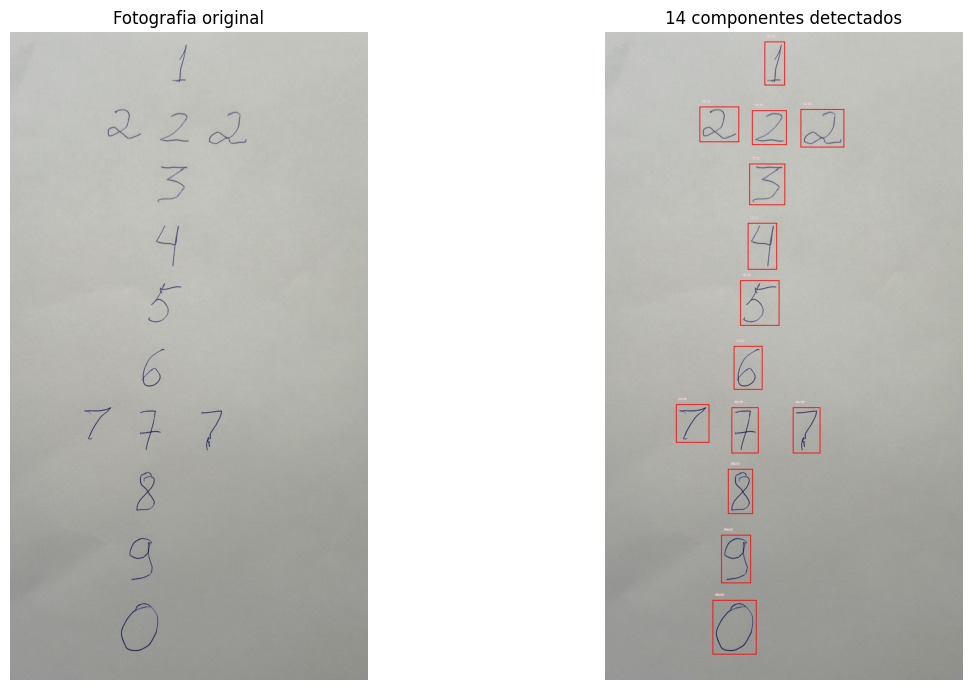

In [20]:
DRIVE_ID = "10EQDYCGKhzbUb2foNdjw0aXNzow1q9Fb"
image_path = ROOT / "data" / "own_digits" / "Numeros_manuscritos.jpg"
url = f"https://drive.google.com/uc?export=download&id={DRIVE_ID}"
urllib.request.urlretrieve(url, image_path)
with Image.open(image_path) as check:
    check.verify()
origem_imagem = "Google Drive"

EXPECTED = [1, 2, 2, 2, 3, 4, 5, 6, 7, 7, 7, 8, 9, 0]
handwritten_result = evaluate_handwritten_sheet(
    root=ROOT,
    image_path=image_path,
    expected_labels=EXPECTED,
    threshold=10.0,
    dilation_iterations=1,
)
print("Origem:", origem_imagem)
print("Dígitos detectados:", handwritten_result["segmentation"]["detected_digits"])
print("Campeão:", handwritten_result["champion"], "| acurácia:", handwritten_result["champion_accuracy"])

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(Image.open(image_path)); axes[0].set_title("Fotografia original"); axes[0].axis("off")
axes[1].imshow(Image.open(ROOT / "outputs" / "figures" / "handwritten_detection.jpg")); axes[1].set_title("14 componentes detectados"); axes[1].axis("off")
plt.tight_layout(); plt.show()

In [21]:
# Resumo a validação externa por modelo: acertos, tamanho da amostra, confiança média e acurácia.
preds = pd.read_csv(ROOT / "outputs" / "tables" / "handwritten_predictions.csv")
hand_summary = preds.groupby("model", sort=False).agg(
    correct=("correct","sum"), total=("correct","size"), mean_confidence=("confidence","mean")
).reset_index()
hand_summary["accuracy"] = hand_summary["correct"] / hand_summary["total"]
display(hand_summary)


,model,correct,total,mean_confidence,accuracy
0,Logistic Regression,9,14,0.618226,0.642857
1,Random Forest,11,14,0.520089,0.785714
2,MLP Keras,14,14,0.857042,1.000000


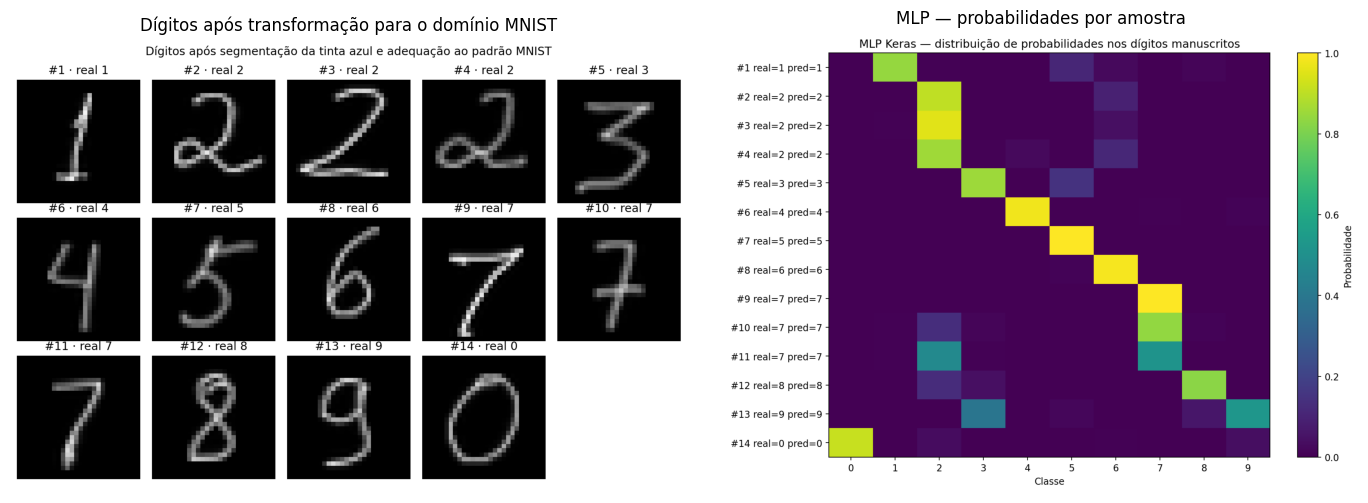

In [22]:
# Coloco lado a lado o pré-processamento 28×28 e as probabilidades da MLP para relacionar imagem e decisão.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(Image.open(ROOT / "outputs" / "figures" / "handwritten_processed_grid.png"))
axes[0].set_title("Dígitos após transformação para o domínio MNIST"); axes[0].axis("off")
axes[1].imshow(Image.open(ROOT / "outputs" / "figures" / "handwritten_mlp_probabilities.png"))
axes[1].set_title("MLP — probabilidades por amostra"); axes[1].axis("off")
plt.tight_layout(); plt.show()


In [23]:
# Exibo cada manuscrito com rótulo esperado, predição, confiança e indicador de acerto para permitir auditoria amostra a amostra.
# Tabela completa: rótulo esperado, predição, confiança e acerto por modelo.
display(preds)


,sample,expected,model,predicted,confidence,correct
0,1,1,Logistic Regression,1,0.625089,True
1,1,1,Random Forest,1,0.443750,True
2,1,1,MLP Keras,1,0.842280,True
3,2,2,Logistic Regression,2,0.981982,True
4,2,2,Random Forest,2,0.568750,True
5,2,2,MLP Keras,2,0.905266,True
6,3,2,Logistic Regression,2,0.444050,True
7,3,2,Random Forest,2,0.468750,True
8,3,2,MLP Keras,2,0.953438,True
9,4,2,Logistic Regression,2,0.710412,True


### **6.2 Interpretação dos manuscritos**

- Regressão Logística: **9/14 = 64,29%**, com confiança média de aproximadamente **61,82%**;
- Random Forest: **11/14 = 78,57%**, com confiança média de aproximadamente **52,01%**;
- **MLP Keras: 14/14 = 100,00%**, com confiança média de aproximadamente **85,70%**.

Nesta folha específica, a MLP apresentou o melhor desempenho, acertando os **14 dígitos manuscritos**, inclusive diante das diferentes grafias de 2 e 7.

Esse resultado, entretanto, deve ser interpretado como uma **demonstração externa do pipeline**, e não como validação populacional. A amostra contém apenas 14 dígitos, todos escritos pelo mesmo autor.

O experimento também evidencia a importância do pré-processamento: segmentação, redimensionamento, centralização e normalização aproximam a fotografia real do padrão visual utilizado no treinamento com o MNIST.


## **7. Conclusões**

### **7.1 Relevância e aplicabilidade do projeto**

O projeto implementou um **pipeline completo de classificação supervisionada multiclasse**, partindo da exploração das 70.000 imagens do MNIST e avançando por pré-processamento, divisão estratificada, treinamento, seleção de hiperparâmetros, avaliação independente, análise de robustez OOD e inferência sobre dígitos manuscritos reais.

A comparação entre modelos mostrou que uma avaliação adequada não deve considerar apenas acurácia. Também foram analisados F1 ponderado, padrões de erro, custo computacional, incerteza e comportamento diante de entradas diferentes das utilizadas no treinamento.

---

### **7.2 Desempenho comparativo dos modelos**

A seleção do modelo foi realizada exclusivamente com os conjuntos de **treino e validação**, mantendo o conjunto de teste fora dessa decisão.

Na validação, a Regressão Logística obteve aproximadamente **92,34% de Accuracy**, o Random Forest **96,79%** e a **MLP Keras 97,59%**, sendo esta última selecionada como modelo campeão.

Após o congelamento da seleção, os modelos foram avaliados no conjunto independente de **14.000 imagens de teste**. Os resultados foram:

- **Regressão Logística:** 92,05% de Accuracy e 92,03% de F1 ponderado;
- **Random Forest:** 96,64% de Accuracy e 96,63% de F1 ponderado;
- **MLP Keras:** 97,50% de Accuracy e aproximadamente 97,50% de F1 ponderado.

A MLP manteve, portanto, o melhor desempenho também em dados que não participaram da seleção do modelo.

---

### **7.3 Custo computacional e tempo de processamento**

Nesta execução, o custo do protocolo de seleção foi de aproximadamente:

- **518,93 s** para Regressão Logística;
- **713,46 s** para Random Forest;
- **115,78 s** para MLP Keras.

Na inferência das **14.000 imagens de teste**, os tempos foram aproximadamente:

- **0,055 s** para Regressão Logística;
- **0,725 s** para Random Forest;
- **0,137 s** para MLP Keras.

A Regressão Logística foi a mais rápida na inferência em lote. A MLP, por sua vez, apresentou o **melhor desempenho preditivo** e o **menor custo de seleção neste protocolo específico**.

Os valores de tempo dependem do hardware, das bibliotecas, do paralelismo e da estratégia utilizada para ajuste de hiperparâmetros. Por isso, devem ser interpretados como resultados desta execução, e não como uma comparação computacional universal entre algoritmos.

---

### **7.4 Diagnóstico dos erros**

As matrizes de confusão confirmaram a mesma ordem observada nas métricas agregadas.

Na Regressão Logística, a confusão mais frequente foi **4→9**, com 55 ocorrências, seguida de **3→5**, com 51.

No Random Forest, o erro mais frequente também foi **4→9**, mas reduzido para 34 casos.

Na MLP Keras, os erros ficaram mais concentrados em ambiguidades visuais, principalmente **9→4**, com 38 casos, além de confusões como **9→7** e **3→5**.

Esses resultados mostram que o aumento de capacidade não linear reduziu de forma consistente os erros sistemáticos observados nos modelos anteriores.

---

### **7.5 Robustez, OOD e falsa certeza**

No experimento de *Class Masking*, os dígitos **4 e 7** foram completamente removidos do treinamento e da validação do modelo restrito. A rede passou a possuir somente oito classes de saída.

Foram avaliadas **2.824 imagens OOD (Out-of-Distribution)** correspondentes às classes ocultas.

A Maximum Softmax Probability (MSP) média foi de aproximadamente **98,64% nas classes conhecidas** e **87,33% nas classes OOD**. Paralelamente, a entropia média aumentou de aproximadamente **0,039 para 0,337**, indicando maior incerteza diante dos dígitos desconhecidos.

Entretanto, algumas amostras de 4 e 7 ainda receberam probabilidades próximas de **100%** para classes incorretas. Esse comportamento evidencia o fenômeno de **overconfidence ou falsa certeza**: uma probabilidade Softmax elevada não garante que a entrada pertença ao domínio conhecido pelo modelo.

---

### **7.6 Generalização para os números manuscritos**

O pipeline de imagens próprias detectou corretamente os **14 dígitos manuscritos esperados**.

Os resultados foram:

- **Regressão Logística:** 9/14, ou 64,29%;
- **Random Forest:** 11/14, ou 78,57%;
- **MLP Keras:** 14/14, ou 100,00%.

A confiança média da MLP nas 14 amostras foi de aproximadamente **85,70%**.

Nesta folha específica, portanto, a MLP transferiu melhor o padrão aprendido no MNIST para uma escrita real do autor.

Esse resultado não constitui, entretanto, uma validação populacional, pois foram utilizadas apenas 14 amostras de uma única pessoa. O teste deve ser entendido como uma **demonstração externa controlada da capacidade do pipeline**.

---

### **7.7 Principais conclusões**

Os resultados permitem destacar quatro conclusões principais.

**Primeiro**, a separação rigorosa entre treino, validação e teste permitiu selecionar os modelos sem utilizar o conjunto empregado posteriormente na avaliação final.

**Segundo**, a MLP Keras apresentou o melhor desempenho preditivo, alcançando **97,50% de Accuracy no teste independente**, superior ao Random Forest e à Regressão Logística.

**Terceiro**, o experimento OOD mostrou que modelos neurais podem demonstrar maior incerteza diante de classes desconhecidas e, ao mesmo tempo, produzir previsões erradas com confiança extremamente elevada.

**Quarto**, o teste com imagens manuscritas confirmou que o pré-processamento é parte essencial do sistema, pois imagens reais precisam ser transformadas para um padrão próximo daquele observado durante o treinamento.

---

### **7.8 Limitações e melhorias futuras**

As principais limitações do projeto são o uso de uma **MLP densa**, que não explora explicitamente a estrutura espacial das imagens como uma CNN, a utilização de manuscritos de apenas um autor e a ausência de um detector OOD dedicado.

Como evolução futura, podem ser avaliadas **CNNs (Convolutional Neural Networks)**, técnicas de *data augmentation*, calibração de confiança, métricas formais de OOD como AUROC, reconhecimento *open-set* e validação com manuscritos de diferentes pessoas.

Também podem ser exploradas técnicas de explicabilidade, como Grad-CAM, e formatos de implantação como TensorFlow Lite ou ONNX.


## **8. Reprodutibilidade e execução**

O notebook contém diretamente as funções necessárias às fases científicas e não importa módulos Python do computador do autor. Os artefatos são criados em diretório relativo do próprio ambiente de execução. O MNIST é baixado pela API do TensorFlow/Keras e a fotografia manuscrita é obtida por Google Drive.

Os modelos treinados, índices do split, métricas, matrizes e evidências são persistidos durante a execução. O arquivo `requirements.txt` registra as versões da entrega.

### **8.1 Redundância do dataset**

Para reduzir o risco de falha por indisponibilidade temporária da fonte primária, o carregamento do MNIST segue três camadas: **(1)** API oficial TensorFlow/Keras; **(2)** cópia redundante pública no Google Drive; **(3)** upload manual no Colab. O backup é validado pelo SHA-256 oficial antes do uso, evitando que um arquivo incompleto ou alterado seja aceito silenciosamente.

- Pasta pública de apoio: https://drive.google.com/drive/folders/1eYu_wF3QCTdG7bANNnC7jG7GHPmpnSwP
- Backup público `mnist.npz`: https://drive.google.com/file/d/1x6s9JFgN5AVv72ZleY2Jp5pyKo-VgPn-/view
- SHA-256 esperado: `731c5ac602752760c8e48fbffcf8c3b850d9dc2a2aedcf2cc48468fc17b673d1`


In [24]:
# Recarrego os modelos persistidos e confronto as previsões para verificar que a serialização preservou o comportamento.
# Auditoria final: integridade, persistência e critérios técnicos essenciais.
lr_reload = joblib.load(ROOT / "artifacts" / "models" / "logistic_regression.joblib")
rf_reload = joblib.load(ROOT / "artifacts" / "models" / "random_forest.joblib")
mlp_reload = tf.keras.models.load_model(ROOT / "artifacts" / "models" / "mlp.keras")
reload_checks = {
    "lr": bool(np.array_equal(lr_reload.predict(X_lr_test), predictions["Logistic Regression"])),
    "rf": bool(np.array_equal(rf_reload.predict(X_f32_test), predictions["Random Forest"])),
    "mlp": bool(np.array_equal(predict_labels(mlp_reload, X_f32_test), predictions["MLP Keras"])),
}

audit = {
    "MNIST 70.000 x 784": X_raw.shape == (70000, 784),
    "10 classes": np.array_equal(np.unique(y), np.arange(10)),
    "split 70/10/20": (len(train_idx), len(val_idx), len(test_idx)) == (49000,7000,14000),
    "normalizacao 0-1": float(X_f32_train.min()) >= 0 and float(X_f32_train.max()) <= 1,
    "3 modelos": set(models) == {"Logistic Regression","Random Forest","MLP Keras"},
    "3 matrizes 10x10": all(cm.shape == (10,10) for cm in confusions.values()),
    "classes ocultas": tuple(DEFAULT_HIDDEN) == (4,7) and int(hidden_mask.sum()) > 0,
    "14 manuscritos": handwritten_result["segmentation"]["detected_digits"] == 14,
    "MLP 14/14": handwritten_result["champion"] == "MLP Keras" and handwritten_result["champion_accuracy"] == 1.0,
    "reload modelos": all(reload_checks.values()),
}
display(pd.Series(audit, name="PASS"))
assert all(audit.values())

run_summary = {
    "run_mode":"NOTEBOOK_FULL", "seed":SEED,
    "split":{"train":49000,"validation":7000,"test":14000},
    "champion_selected_on_validation":champion,
    "test_metrics":test_metrics,
    "reload_checks":reload_checks,
    "ood":ood_results,
    "own_image":handwritten_result,
    "status":"COMPLETE",
}
(ROOT / "artifacts" / "run_summary.json").write_text(json.dumps(run_summary, indent=2, ensure_ascii=False), encoding="utf-8")
print("AUDITORIA FINAL: PASS — execução completa confirmada.")


,PASS
MNIST 70.000 x 784,True
10 classes,True
split 70/10/20,True
normalizacao 0-1,True
3 modelos,True
3 matrizes 10x10,True
classes ocultas,True
14 manuscritos,True
MLP 14/14,True
reload modelos,True


AUDITORIA FINAL: PASS — execução completa confirmada.
